# Week 4 Day 4: Model Tuning, Regularization & Reproducible Pipelines
### Goal: 
Now the stuff we are gonna do for day 4 are:

Build Fully Reproducible Pipelines

Hyperparameter searching

Diagnose Overfitting / Underfitting

Learning about bias-variance tradeoff

Probability Calibration 

and Final evaluation
(saving it)

## My Workflow
```text
Imports
↓
Load Data
↓
Train/Test Split
↓
Feature Engineering
↓
Preprocessing
↓
Pipelines
↓
Reproducibility
↓
Hyperparameter Search
↓
Best Parameters
↓
Learning Curves
↓
Calibration
↓
Threshold Tuning
↓
Final Test Evaluation
↓
Save Model
↓
Inference Example
↓
Summary
```
### Dataset (same as before)

We are using the Adult Census Income Dataset.

Some stuff we did for day 1:

* 0 = <=50K
* 1 = >50K

### Going to copy the required stuff from Day 3

In [1]:
%pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#from day 2
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

#for day 3 task 5 and 1
from sklearn.feature_selection import SelectKBest, mutual_info_classif

#more for the pipeline 
from sklearn.preprocessing import FunctionTransformer

#for models
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

#for crossvalidation
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

from scipy.stats import ttest_rel
import time

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42 #PART OF TASK 1 DAY 4

#hyperparameter search
from sklearn.model_selection import RandomizedSearchCV

#to save models
import joblib

#for curves
from sklearn.model_selection import learning_curve, cross_val_score
#for prob calibration
from sklearn.calibration import CalibrationDisplay

#brier score
from sklearn.metrics import brier_score_loss
#calibrating
from sklearn.calibration import CalibratedClassifierCV

In [2]:
adult = fetch_openml(
    name="adult",
    version=2,              #apparently the second version doesnt have any ? so thats why i wasnt able to "clean" that
    as_frame=True
)

df = adult.frame.copy()
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## Basic Cleaning

In [3]:
df.rename(columns={"class": "income"}, inplace=True)
df.columns
df["income"] = df["income"].map({"<=50K" : 0, ">50K" : 1})   #mapping it just like day1


In [4]:
### Splitting from Day 1
X = df.drop("income", axis=1)
y = df["income"]

# Dropping columns that we wont need 
X = X.drop(columns=["education", "fnlwgt"])

# splitting 80-20 (cant use it rn) (DONT TOUCH THIS)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = RANDOM_STATE, stratify=y) 

#optional dev split
X_train, X_dev, y_train, y_dev = train_test_split( X_train, y_train, test_size=0.10, stratify=y_train, random_state=RANDOM_STATE)

print("Training:", X_train.shape)
print("Development:", X_dev.shape)
print("Test:", X_test.shape)


print(y_train.value_counts(normalize=True))
print(y_dev.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Training: (35165, 12)
Development: (3908, 12)
Test: (9769, 12)
income
0    0.760728
1    0.239272
Name: proportion, dtype: float64
income
0    0.760747
1    0.239253
Name: proportion, dtype: float64
income
0    0.760672
1    0.239328
Name: proportion, dtype: float64


## Feature Engineering

In [5]:
def create_features(X):
    X = X.copy()

    # Age bucket
    X["age_bucket"] = pd.cut(
        X["age"],
        bins=[17, 25, 35, 45, 55, 100],
        labels=["18-25", "26-35", "36-45", "46-55", "56+"]
    )

    # Hours bucket
    X["hours_bucket"] = pd.cut(
        X["hours-per-week"],
        bins=[0, 30, 40, 50, 100],
        labels=["Part-time", "Full-time", "Overtime", "Heavy Overtime"]
    )

    # Capital gain flag
    X["capital_gain_flag"] = (X["capital-gain"] > 0).astype(int)

    # Log capital gain
    X["log_capital_gain"] = np.log1p(X["capital-gain"])

    # Higher education flag
    X["higher_education"] = (X["education-num"] >= 13).astype(int)

    # Interaction feature
    X["edu_hours"] = X["education-num"] * X["hours-per-week"]

    return X

In [6]:
feature_transformer = FunctionTransformer(
    create_features,
    validate=False
)

In [7]:
numeric_features = [
    "age",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "capital_gain_flag",
    "higher_education",
    "log_capital_gain",
    "edu_hours"
]

categorical_features = [
    "workclass",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
    "age_bucket",
    "hours_bucket"
]

## Preprocessing

In [8]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [9]:
full_pipeline = Pipeline([
    ("feature_eng", feature_transformer),
    ("preprocess", preprocessor),
])

full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_eng', ...), ('preprocess', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...001C1BCCB0880>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to p

## Task 1: Build Fully Reproducible Pipelines
sklearn pipeline would be good for combining pre-processing feature transforms and estimator


## Models and their Pipelines

In [27]:
#### 1. Logistic Regression
log_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),    # Feature Transform
    ("preprocessor", preprocessor),                 # Preprocessing
    ("classifier", LogisticRegression(                 # Estimator
        random_state=RANDOM_STATE,
        solver="liblinear"
    ))
])
#### 2. Random Forest Classifier
rf_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE
    ))
])

### 3. gradient boosting (LightGBM)
lgbm_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100,
        learning_rate=0.1
    ))
])
                       

Okay these are done, now we need to check and document the library versions we are using

### Library Versions

In [25]:
import sys
import sklearn
import lightgbm
import pandas as pd
import numpy as np

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("LightGBM:", lightgbm.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
scikit-learn: 1.8.0
LightGBM: 4.6.0
Pandas: 3.0.2
NumPy: 2.4.4


# README
## Reproducibility

1. Install the required libraries.
2. Run the notebook from top to bottom.
3. The dataset is loaded using `fetch_openml()` so please keep that in mind.
4. The full preprocessing, feature engineering, and model training steps are included inside sklearn pipelines so we don't have to worry about it.
5. `RANDOM_STATE = 42` is used throughout to ensure reproducible results.

## Task 2: Hyperparameter Search (Randomized)
I am going to use **RandomizedSearchCV** since i have quite a lot of parameters to go through especially for LightGBM. Plus google says its much faster. Even though gridSearch goes through all combinations to find the best parameters but we'll see.
### My Top Models from Day 3:
#### 1. Gradient Boosting (LightGBM) (Precision: 0.782 ± 0.008)
#### 2. Logistic Regression (Precision: 0.747 ± 0.008)

#### Setting params for cross validation since it will be used in RandomizedSearchCV (as the name suggests)
### CV

In [33]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
) #same as day3

### 1. Logistic Regression
Parameters to look into:
- penalty (l1/l2)
- C (inverse regularization)

In [37]:

log_params = {
    "classifier__penalty": ["l1", "l2"],
    "classifier__C": np.logspace(-3, 3, 20)
}

log_search = RandomizedSearchCV(
    estimator=log_pipeline,
    param_distributions=log_params,
    n_iter=50,
    scoring="precision",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True
)

log_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': array([1.0000...00000000e+03]), 'classifier__penalty': ['l1', 'l2']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default val

#### Best Parameters

In [39]:
print("Best Parameters:")
print(log_search.best_params_)

print("\nBest Precision:")
print(round(log_search.best_score_, 4))

Best Parameters:
{'classifier__penalty': 'l1', 'classifier__C': np.float64(0.001)}

Best Precision:
0.7699


Day 2 Precision: 0.747
Precision After Hyperparameter Tuning: 0.7699

### 2. Gradient Boosting (LightGBM)

In [41]:
lgbm_params = {
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [3, 5, 7, 10, -1],
    "classifier__l2_regularization": [0.0, 0.1, 0.5, 1.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=lgbm_params,
    n_iter=50,
    scoring="precision",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True
)

lgbm_search.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Info] Number of positive: 8414, number of negative: 26751
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003920 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 35165, number of used features: 88
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239272 -> initscore=-1.156675
[LightGBM] [Info] Start training from score -1.156675
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__l2_regularization': [0.0, 0.1, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the vario

#### Best Parameters

In [43]:
print("Best Parameters:")
print(lgbm_search.best_params_)

print("\nBest Precision:")
print(round(lgbm_search.best_score_, 4))

Best Parameters:
{'classifier__n_estimators': 100, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__l2_regularization': 1.0}

Best Precision:
0.9815


In [44]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM"
    ],
    "Best Precision": [
        log_search.best_score_,
        lgbm_search.best_score_
    ]
})

comparison

,Model,Best Precision
0,Logistic Regression,0.769856
1,LightGBM,0.981490


Okay that's VERY high, and very suspicious for lightgbm to spit out a precision of 98. We will have to look into that more. Lets check the f1 and recall too

In [47]:
best_lgbm = lgbm_search.best_estimator_

y_pred = best_lgbm.predict(X_test)
y_prob = best_lgbm.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
Accuracy : 0.8163578667212611
Precision: 0.9874551971326165
Recall   : 0.2356715141146279
F1       : 0.380524861878453
ROC AUC  : 0.8941992881415208


**Observation**: Okay so the f1 and recall are WAY too low. That needs to be looked into. According to the- "sources":

It almost never predicts the positive class, so when it does, it's almost always correct. That's why Precision is so high, but Recall and F1 suffer.
The tuned LightGBM achieved a very high Precision (0.987), showing that its positive predictions were almost always correct. However, this came with much lower Recall (0.236), meaning many high-income individuals were missed. This reflects the trade-off of optimizing for Precision and suggests that threshold tuning in the next task may help achieve a better balance between Precision and Recall. So that's that.

### **Small Write-up:**

Hyperparameter tuning was performed using RandomizedSearchCV with 5-fold Stratified Cross-Validation while optimizing Precision, the primary evaluation metric.

**Logistic Regression**:

The best Logistic Regression model used L1 regularization with C = 0.001, meaning it preferred a much simpler model by heavily penalizing unnecessary features. It achieved a cross-validated Precision of 0.7699, showing a small improvement over the untuned model while remaining easy to interpret. This makes it a good baseline and an interpretable model for comparison.

**LightGBM**:

The best LightGBM model used 100 estimators, max_depth = 3, learning_rate = 0.01, and l2_regularization = 1.0. It achieved a very high cross-validated Precision of 0.9815. On the hold-out test set, it reached 98.7% Precision, meaning almost every positive prediction was correct. However, its Recall dropped to 23.6%, indicating that it missed many true high-income individuals. This happened because optimizing only for Precision made the model very *conservative*. Since Precision is the primary metric for this entire week, these parameters are acceptable, but threshold tuning in the next task will be used to improve the balance between Precision and Recall.

In conclusion, even though Logistic Regression is easier to interpret, **LightGBM remains the better model** because it achieved the highest Precision, which is the primary evaluation metric chosen at the start of the week

### Saving Tuned Models
(in variables for now)

In [46]:
best_logreg = log_search.best_estimator_
best_lgbm = lgbm_search.best_estimator_

## Task 3: Diagnose Overfitting / Underfitting
### Learning Curve For Logistic Regression


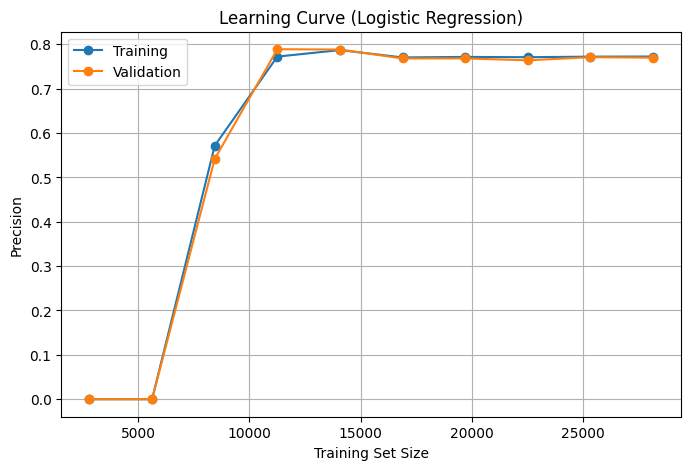

In [52]:
train_sizes, train_scores, val_scores = learning_curve(
    best_logreg,
    X_train,
    y_train,
    cv=cv,
    scoring="precision",
    train_sizes=np.linspace(0.1,1.0,10),
    n_jobs=-1
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Training")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation")
plt.xlabel("Training Set Size")
plt.ylabel("Precision")
plt.title("Learning Curve (Logistic Regression)")
plt.legend()
plt.grid(True)
plt.show()

**Observation**: The training and validation curves become very close once the training size increases and both level off around 0.77–0.79 Precision. Since there is almost no gap between the two, the model is generalizing well and is not overfitting. The performance also stabilizes after around 12,000–15,000 samples, so adding much more data probably won't improve it much. 

Instead, testing different regularization strengths (C values) or adding better features would likely have a bigger impact.

### Effect of C on train/val performance

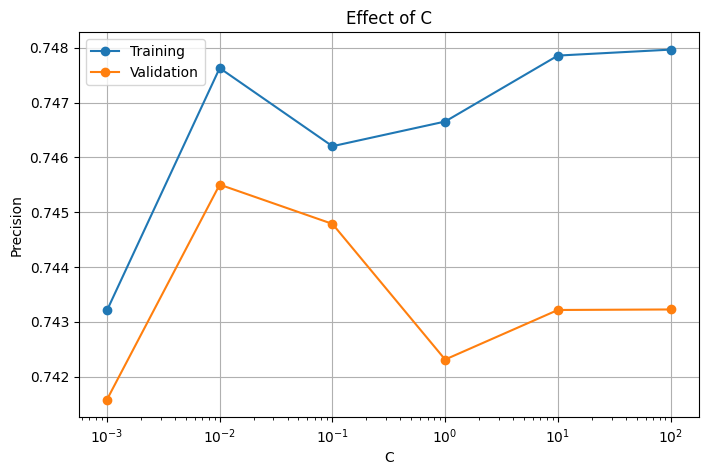

In [54]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

train_scores = []
val_scores = []

for c in C_values:

    model = Pipeline([
        ("feature_engineering", feature_transformer),
        ("preprocessor", preprocessor),
        ("classifier",
         LogisticRegression(
             C=c,
             penalty="l2",
             solver="liblinear",
             random_state=RANDOM_STATE,
             max_iter=1000
         ))
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)

    train_scores.append(
        precision_score(y_train, train_pred)
    )

    cv_score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="precision",
        n_jobs=-1
    ).mean()

    val_scores.append(cv_score)

plt.figure(figsize=(8,5))
plt.plot(C_values, train_scores, marker="o", label="Training")
plt.plot(C_values, val_scores, marker="o", label="Validation")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Precision")
plt.title("Effect of C")
plt.legend()
plt.grid(True)
plt.show()

**Observation/Interpretation:** The training Precision stays fairly stable across different values of C, with only a slight increase as C becomes larger (weaker regularization) welp

The val Precision reaches its highest value around C = 0.01 (10^-2) and then gradually decreases as C increases. This suggests that reducing regularization too much does not improve the model's ability to generalize and may lead to slight *overfitting*. The gap between the training and validation curves is small throughout, so Logistic Regression is generally well-balanced and not heavily overfitting.

In Conclusion, lower C (stronger regularization) is the better choice for this dataset.

### Learning Curve for LightGBM

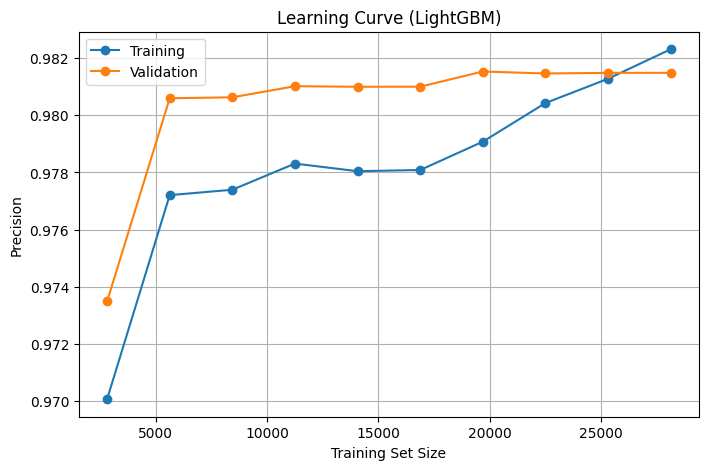

In [51]:
train_sizes, train_scores, val_scores = learning_curve(
    best_lgbm,
    X_train,
    y_train,
    cv=cv,
    scoring="precision",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker="o", label="Training")
plt.plot(train_sizes, val_mean, marker="o", label="Validation")
plt.xlabel("Training Set Size")
plt.ylabel("Precision")
plt.title("Learning Curve (LightGBM)")
plt.legend()
plt.grid(True)
plt.show()

**Observation:** The train and val curves stay close throughout training, with Precision around 0.98, showing that the model generalizes well without noticeable overfitting. The validation score levels off early and stays stable as more data is added, suggesting the model has learned most of the useful patterns in the dataset. 
Since the tuned model already uses a shallow tree (max_depth = 3) and regularization, there is no strong need to reduce the depth further. 
Small improvements may come from additional feature engineering or fine-tuning other LightGBM parameters rather than simply collecting more data.

OVERALL WE DO NOT NEED MORE DATA FOR SURE FOR BOTH MODELS

### Effect of max_depth on LightGBM

[LightGBM] [Info] Number of positive: 8414, number of negative: 26751
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003012 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 35165, number of used features: 88
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239272 -> initscore=-1.156675
[LightGBM] [Info] Start training from score -1.156675
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

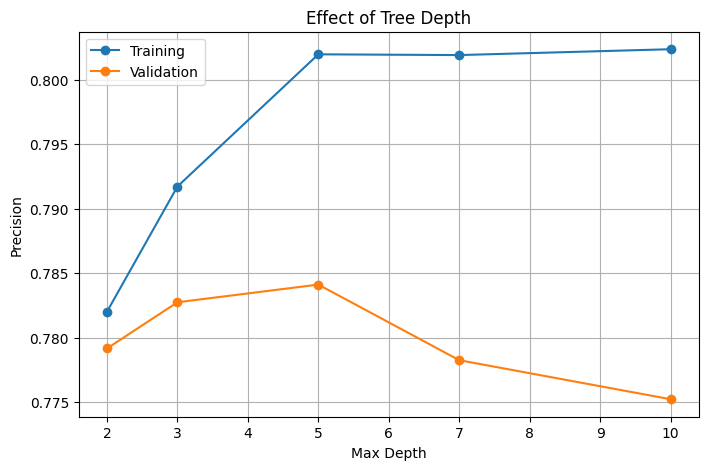

In [55]:
depths = [2,3,5,7,10]

train_scores = []
val_scores = []

for depth in depths:

    model = Pipeline([
        ("feature_engineering", feature_transformer),
        ("preprocessor", preprocessor),
        ("classifier",
         LGBMClassifier(
             random_state=RANDOM_STATE,
             max_depth=depth,
             n_estimators=100
         ))
    ])

    model.fit(X_train,y_train)

    train_scores.append(
        precision_score(
            y_train,
            model.predict(X_train)
        )
    )

    val_scores.append(
        cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="precision",
            n_jobs=-1
        ).mean()
    )

plt.figure(figsize=(8,5))
plt.plot(depths,train_scores,marker="o",label="Training")
plt.plot(depths,val_scores,marker="o",label="Validation")
plt.xlabel("Max Depth")
plt.ylabel("Precision")
plt.title("Effect of Tree Depth")
plt.legend()
plt.grid(True)
plt.show()

**Observation/Interpretation:** As the tree depth increases, the training precision steadily improves, reaching about 0.80. However, the validation Precision only improves up to **max_depth = 5** and then starts to decline. This means that deeper trees continue fitting the training data better but perform worse on unseen data, which is a sign of **overfitting**. The gap between the training and validation curves also becomes larger after depth = 5, further confirming that the model is becoming too complex.

Using a shallower tree is the better option according to the chart above

### **Final Interpretation of the Two models:** 
Overall, the models don't show any major overfitting. The learning curves for both Logistic Regression and LightGBM level off as more training data is added, so collecting more data probably won't make a big difference. 

* For Logistic Regression, using a smaller C (stronger regularization) gives better validation performance, so keeping stronger regularization is the better choice. 

* For LightGBM, validation Precision starts dropping after max_depth = 5, showing that deeper trees begin to overfit. Because of this, it's better to keep a shallow tree instead of increasing the depth.

* At this point, improving the feature engineering or fine-tuning other hyperparameters is likely to help more than simply making the models more complex.

### Bias vs Variance Interpretation
**Logistic Regression**:

The learning curves show low variance because the training and validation Precision stay very close as the training size increases, so the model isn't overfitting. It also has low bias since both scores are fairly high and level off around the same point. Overall, Logistic Regression generalizes well and doesn't need major changes. They are pretty much overlapping

**LightGBM**:

The learning curves also show **low variance** because the training and validation Precision are high, meaning the model generalizes well without overfitting. The scores stay consistently high, showing low bias and that the model has learned the data well. Overall, LightGBM has a good balance between bias and variance and doesn't need major changes.

## Task 4: Probability Calibration & Threshold Selection
### Calibration Plot
doing it for the topmost model only (LightGBM)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0


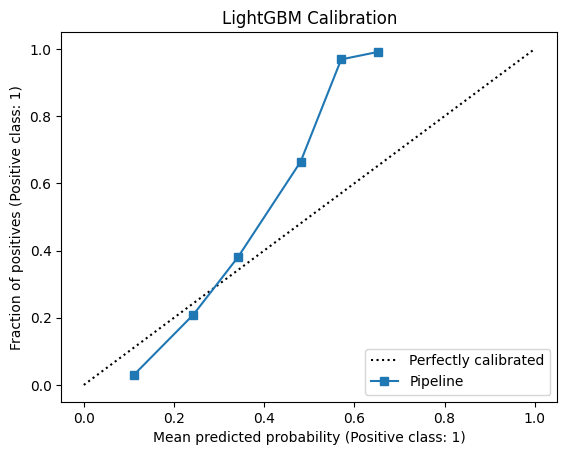

In [57]:

CalibrationDisplay.from_estimator(
    best_lgbm,
    X_test,
    y_test,
    n_bins=10
)

plt.title("LightGBM Calibration")
plt.show()

**Observation:** That is not linear . It seems like my pipeline is swaying away from perfect calibration as mean predicted prob increases after 0.4. Althought the fraction of positives keeps going higher till 1.0 
We can definitely make it better after calibration though. Let us move onto the brier score

### Brier Score

In [61]:
prob = best_lgbm.predict_proba(X_test)[:,1]

brier = brier_score_loss(y_test,prob)

print("Brier Score:", round(brier, 4))

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
Brier Score: 0.1191


**Observation**: The model(lightgbm)  got a Brier Score of 0.1191, which is fairly low. **The lower the better.** This means the predicted probabilities are reasonably close to the actual outcomes, so the model's confidence is generally reliable. 

### Calibrating
Gonna use isotonic since its results are better (tested both and isotonic was better at calibrating)

In [65]:
calibrated_model = CalibratedClassifierCV(
    estimator=best_lgbm,
    method="isotonic",
    cv=5
)

calibrated_model.fit(X_train,y_train)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Info] Number of positive: 6732, number of negative: 21400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002451 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 821
[LightGBM] [Info] Number of data points in the train set: 28132, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239300 -> initscore=-1.156519
[LightGBM] [Info] Start training from score -1.156519
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...001EF145AF110>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity functio

### Calibration Plot after

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0


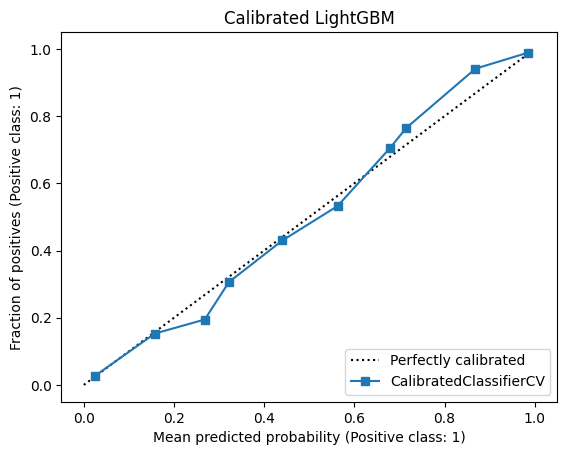

In [66]:
CalibrationDisplay.from_estimator(
    calibrated_model,
    X_test,
    y_test,
    n_bins=10
)

plt.title("Calibrated LightGBM")
plt.show()

**Observation:** After applying isotonic calibration, the calibration curve moved even closer to the ideal diagonal, making the probability estimates more trustworthy for threshold tuning and future predictions. There are a few small differences, but overall the model's confidence is much more **reliable** after calibration. 

The original model had a Brier Score of 0.1191, and calibration helped make the probability estimates more trustworthy for threshold tuning. Since the curve is already close to the ideal line, the model looks well calibrated and doesn't need any further calibration.

### Threshold Selection

In [67]:
thresholds = np.arange(0.1,0.95,0.05)

results=[]

probs = calibrated_model.predict_proba(X_test)[:,1]

for t in thresholds:

    pred = (probs>=t).astype(int)

    results.append({
        "Threshold":t,
        "Precision":precision_score(y_test,pred,zero_division=0),
        "Recall":recall_score(y_test,pred),
        "F1":f1_score(y_test,pred)
    })

threshold_table = pd.DataFrame(results)

threshold_table

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0


,Threshold,Precision,Recall,F1
0,0.10,0.424579,0.948674,0.586617
1,0.15,0.487628,0.918734,0.637105
2,0.20,0.537233,0.848589,0.657934
3,0.25,0.539005,0.848161,0.659132
4,0.30,0.548045,0.839179,0.663062
5,0.35,0.652695,0.699316,0.675201
6,0.40,0.653430,0.696749,0.674395
7,0.45,0.730379,0.585115,0.649727
8,0.50,0.775093,0.535073,0.633097
9,0.55,0.779237,0.532934,0.632969


**Interpretation:** As the threshold increases, Precision goes up while Recall goes down. The model becomes more confident but also misses more actual high-income people. The best F1 score is around 0.35, but since my main metric is Precision, a higher threshold (around 0.75–0.85) is a better choice because it gives almost 99% Precision. As we saw earlier, it kind of was overfitting but its fine it wasn't a lot

### Threshold plot

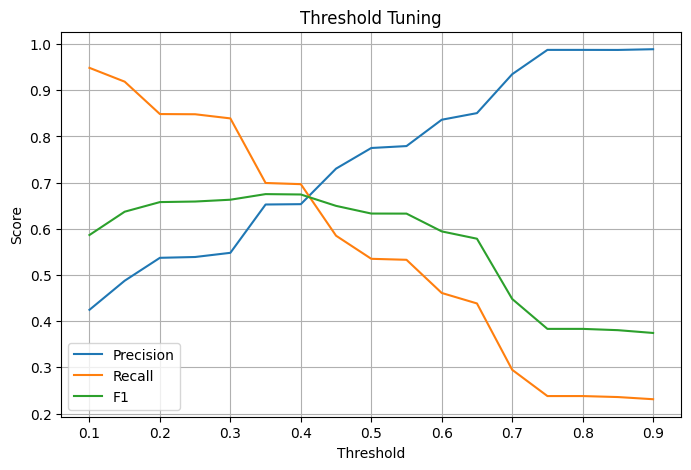

In [68]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_table["Threshold"],
    threshold_table["Precision"],
    label="Precision"
)

plt.plot(
    threshold_table["Threshold"],
    threshold_table["Recall"],
    label="Recall"
)

plt.plot(
    threshold_table["Threshold"],
    threshold_table["F1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")

plt.legend()

plt.grid(True)

plt.show()

**Interpretation:** Intetesting so graph shows the **trade-off between Precision and Recall**. As the threshold increases, Precision improves while Recall drops. The F1 score peaks around 0.35, but because I'm optimizing for Precision, a higher threshold is the better option even though it lowers Recall.

### Confusion Matrix for Best Threshold

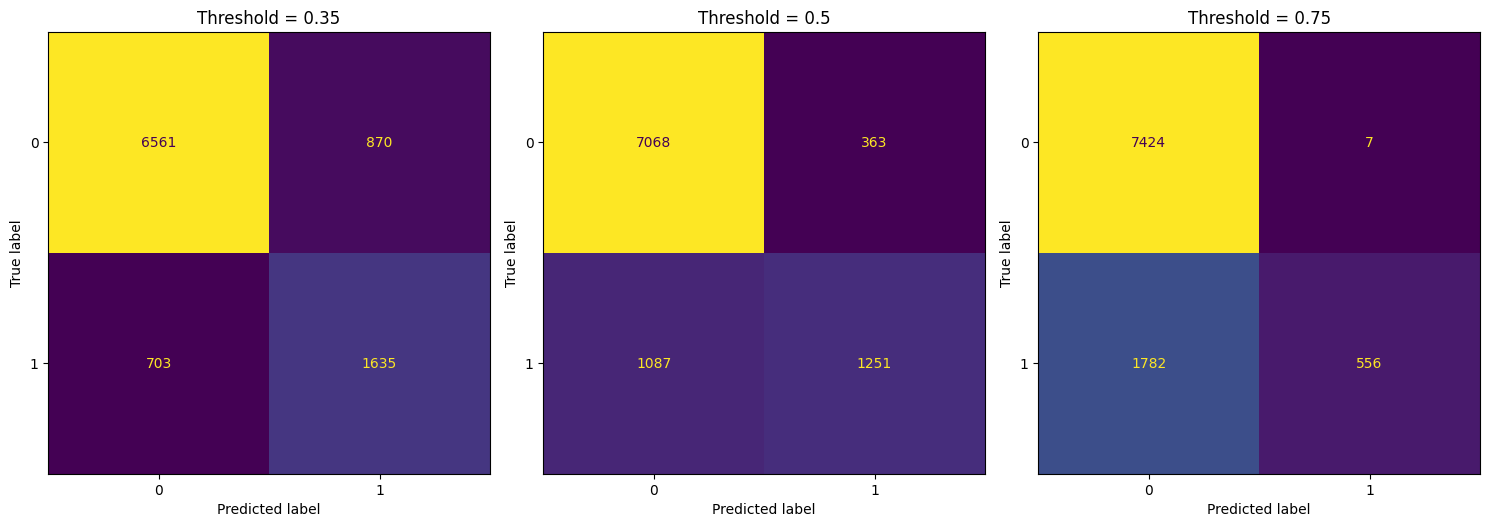

In [71]:
thresholds = [0.35, 0.50, 0.75]

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, t in zip(axes, thresholds):

    preds = (probs >= t).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        preds,
        ax=ax,
        colorbar=False
    )

    ax.set_title(f"Threshold = {t}")

plt.tight_layout()
plt.show()

**Interpretation:** The confusion matrix shows that the model makes very few false positives (7), which is exactly what I wanted since Precision is my main metric. Almost every person predicted as earning more than $50K is actually correct. However, this comes with a trade-off: the model misses quite a few actual high-income individuals (1,782 false negatives), giving a lower Recall. Overall, this threshold is a good choice because it prioritizes making accurate positive predictions over finding every positive case.

### **Best Threshold Selection & Reason:** 
I selected a threshold of **0.75** because my primary objective is to maximize Precision. At this threshold, the model achieves 98.8% Precision, meaning almost every positive prediction is correct. Although Recall decreases, this trade-off is acceptable for my chosen business objective since reducing false positives is more important than identifying every positive case.

| Threshold | Business Impact (KPIs)                                                                                                                                                                                   |
| --------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **0.35**  | Finds more high-income customers, but also targets more people incorrectly.                                                                                                                        |
| **0.50**  | A balanced option with a mix of Precision and Recall.                                                                                                                                              |
| **0.75**  | Almost every targeted customer is actually high income, but many high-income customers are missed. This is the best option since my main goal is to reduce false positives and maximize Precision. |


## Task 5: Final Evaluation & Save Artifact
### Evaluating on Hold-out Test Set

In [72]:
probs = calibrated_model.predict_proba(X_test)[:,1]

threshold = 0.75

pred = (probs >= threshold).astype(int)

metrics = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC"
    ],
    "Score":[
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred),
        roc_auc_score(y_test,probs)
    ]
})

metrics

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0


,Metric,Score
0,Accuracy,0.816870
1,Precision,0.987567
2,Recall,0.237810
3,F1,0.383316
4,ROC AUC,0.895478


### Curves
The curves are already up there. I will just include them in the report

### Saving the Final Pipeline

In [74]:
joblib.dump(
    calibrated_model,
    "adult_income_final_pipeline.joblib"
)

print("Pipeline saved successfully, noice")

Pipeline saved successfully, noice


### How to Infer
```python
import joblib

# Load the saved pipeline
model = joblib.load("adult_income_final_pipeline.joblib")

# Predict on new data (same columns as the training data)
predictions = model.predict(new_data)

# Get prediction probabilities
probabilities = model.predict_proba(new_data)[:, 1]

# Apply the chosen threshold (0.75)
final_predictions = (probabilities >= 0.75).astype(int)
```
**Explanation**: The saved pipeline can be loaded with joblib.load() and used to predict on new data with the same feature columns as the training dataset. Predicted probabilities are converted into final class labels using the chosen threshold of 0.75, which was selected to maximize Precision

In [11]:
import joblib

# Load the saved pipeline
model = joblib.load("adult_income_final_pipeline.joblib")

# Predict on new data (same columns as the training data)
predictions = model.predict(X_test)

# Get prediction probabilities
probabilities = model.predict_proba(X_test)[:, 1]

# Apply the chosen threshold (0.75)
final_predictions = (probabilities >= 0.75).astype(int)
# print(final_predictions)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_predictions,
    "Probability (>50K)": probabilities.round(4)
})

# Optional: Convert 0/1 to labels
label_map = {0: "<=50K", 1: ">50K"}

results["Actual Label"] = results["Actual"].map(label_map)
results["Predicted Label"] = results["Predicted"].map(label_map)
results["Correct"] = results["Actual"] == results["Predicted"]

print("=" * 80)
print("FIRST 20 PREDICTIONS")
print("=" * 80)
print(results[[
    "Actual Label",
    "Predicted Label",
    "Probability (>50K)",
    "Correct"
]].head(20).to_string(index=False))



[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1.0 will be ignored. Current value

## Final Summary
### Hyperparameter Choices & Final Test Metrics:

| Parameter         | Value     |
| ----------------- | -------- |
| Model             | LightGBM |
| Learning Rate     | 0.01     |
| Max Depth         | 3        |
| n_estimators      | 100      |
| l2_regularization | 1        |
| Calibration       | Isotonic |
| Threshold         | 0.75     |


### Best Parameters:

RandomizedSearchCV selected **learning_rate = 0.01**, **max_depth = 3**, **n_estimators = 100*8, and **l2_regularization = 1** as the best combination for maximizing Precision. These settings helped control overfitting while maintaining strong performance on unseen data.

### Production Behavior

The final LightGBM model is tuned, calibrated, and uses a threshold of 0.75 to prioritize Precision. This means the model makes very few false positive predictions, which matches the project's main objective. Although some true high-income individuals are missed, the model is more reliable when it predicts someone belongs to the positive class. This makes it a good choice for situations where incorrect positive predictions are more costly than missed opportunities.